# Laboratory Exercise 1: Linear Regression Implementation

In [2]:
#@title # 1. Data Preprocessing

import pandas as pd
from sklearn.preprocessing import StandardScaler

path = 'datasets_house_prices.csv'
df = pd.read_csv(path)

print("First few rows of the dataset:")
print(df.head())

print("\nMissing values in each column:")
print(df.isnull().sum())

df = df.dropna()

print("\nMissing values after handling:")
print(df.isnull().sum())

features = df[['Size (sqft)', 'Bedrooms', 'Age', 'Proximity to Downtown (miles)']]
target = df['Price']

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

normalized_df = pd.DataFrame(scaled_features, columns=features.columns)
normalized_df['Price'] = target.values

print("\nFirst few rows of the normalized dataset:")
print(normalized_df.head())

First few rows of the dataset:
   Size (sqft)  Bedrooms  Age  Proximity to Downtown (miles)         Price
0         3974         1   97                       2.032719  1.162771e+06
1         1660         5   88                      23.695207  4.900021e+05
2         2094         4   49                       6.440232  6.400737e+05
3         1930         2   28                       8.129315  5.637881e+05
4         1895         1   56                       5.358837  5.651289e+05

Missing values in each column:
Size (sqft)                      0
Bedrooms                         0
Age                              0
Proximity to Downtown (miles)    0
Price                            0
dtype: int64

Missing values after handling:
Size (sqft)                      0
Bedrooms                         0
Age                              0
Proximity to Downtown (miles)    0
Price                            0
dtype: int64

First few rows of the normalized dataset:
   Size (sqft)  Bedrooms       Age  

In [3]:
#@title # 2. Model Implementation

import numpy as np

class LinearRegression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        """
        Fit the linear regression model using the least squares method.
        X: 2D array-like, shape (n_samples, n_features) - Feature matrix
        y: 1D array-like, shape (n_samples,) - Target values
        """
        X = np.hstack([np.ones((X.shape[0], 1)), X])

        X_transpose = X.T
        theta = np.linalg.inv(X_transpose @ X) @ X_transpose @ y
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

    def predict(self, X):
        """
        Predict using the linear regression model.
        X: 2D array-like, shape (n_samples, n_features) - Feature matrix
        """
        return X @ self.coef_ + self.intercept_

X = normalized_df[['Size (sqft)', 'Bedrooms', 'Age', 'Proximity to Downtown (miles)']].values
y = normalized_df['Price'].values

model = LinearRegression()
model.fit(X, y)

print("Model Coefficients (weights):", model.coef_)
print("Model Intercept:", model.intercept_)

def predict_price(features):
    """
    Predict the house price based on input features.
    features: 1D array-like, shape (n_features,) - Input features
    """
    features = np.array(features).reshape(1, -1)
    scaled_features = scaler.transform(features)
    return model.predict(scaled_features)[0]

example_features = [3974, 1, 97, 2.032719038]
predicted_price = predict_price(example_features)
print("Predicted Price for the example features:", predicted_price)


Model Coefficients (weights): [279093.75957568   6865.10416962  -5830.96824417  -8219.86434429]
Model Intercept: 719053.2124580999
Predicted Price for the example features: 1176151.1558759238


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:
#@title # 3. Model Training

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = normalized_df[['Size (sqft)', 'Bedrooms', 'Age', 'Proximity to Downtown (miles)']].values
y = normalized_df['Price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error on the training set:", mse_train)


Mean Squared Error on the training set: 102060369.47883411


Mean Squared Error on the testing set: 103564728.17767784


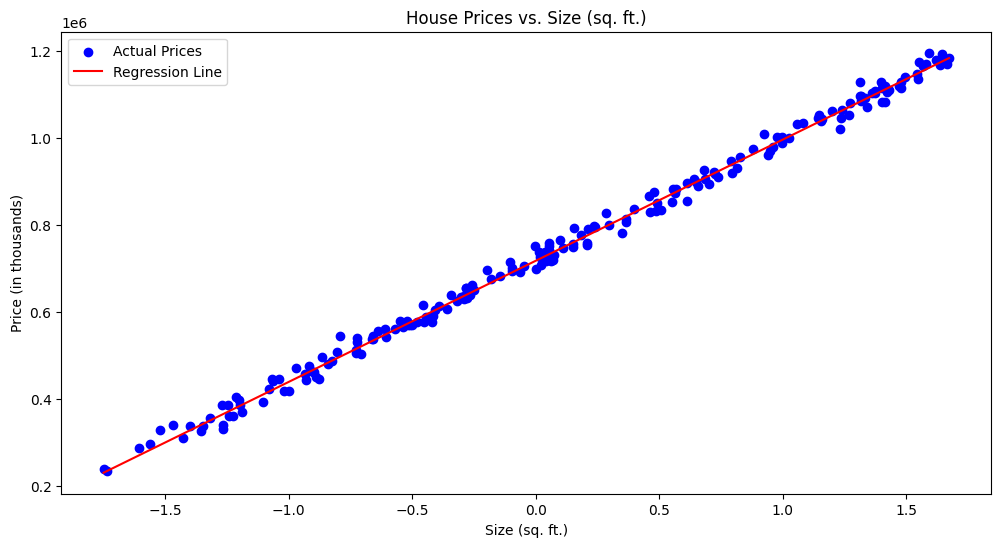

In [5]:
#@title # 4. Model Evaluation

import matplotlib.pyplot as plt

y_test_pred = model.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error on the testing set:", mse_test)

plt.figure(figsize=(12, 6))

plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual Prices')

size_range = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 100).reshape(-1, 1)

mean_bedrooms = np.mean(X_test[:, 1])
mean_age = np.mean(X_test[:, 2])
mean_proximity = np.mean(X_test[:, 3])
grid_features = np.hstack([size_range, np.full((size_range.shape[0], 1), mean_bedrooms),
                            np.full((size_range.shape[0], 1), mean_age),
                            np.full((size_range.shape[0], 1), mean_proximity)])
predicted_prices = model.predict(grid_features)

plt.plot(size_range, predicted_prices, color='red', label='Regression Line')

plt.xlabel('Size (sq. ft.)')
plt.ylabel('Price (in thousands)')
plt.title('House Prices vs. Size (sq. ft.)')
plt.legend()
plt.show()
